In [1]:
import kagglehub
path = kagglehub.dataset_download("atharvasoundankar/ai-developer-productivity-dataset")

Using Colab cache for faster access to the 'ai-developer-productivity-dataset' dataset.


In [2]:
import os
import pandas as pd
if path:
  print(f"Path for data : {os.listdir(path)}")
else:
  print("file path is not found")

filepath = os.path.join(path,'ai_dev_productivity.csv')

dataset = pd.read_csv(filepath)
dataset.head()


Path for data : ['ai_dev_productivity.csv']


,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
0,5.99,600,1,5.8,2,1,0.71,5.4,1
1,4.72,568,2,6.9,5,3,1.75,4.7,1
2,6.30,560,1,8.9,2,0,2.27,2.2,1
3,8.05,600,7,6.3,9,5,1.40,5.9,0
4,4.53,421,6,6.9,4,0,1.26,6.3,1


How does caffeine impact bugs in code?

Can you predict if a dev will succeed today based on distractions and AI tool use?

What’s the optimal balance between AI usage and raw coding time?

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hours_coding      500 non-null    float64
 1   coffee_intake_mg  500 non-null    int64  
 2   distractions      500 non-null    int64  
 3   sleep_hours       500 non-null    float64
 4   commits           500 non-null    int64  
 5   bugs_reported     500 non-null    int64  
 6   ai_usage_hours    500 non-null    float64
 7   cognitive_load    500 non-null    float64
 8   task_success      500 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


**Data Processing**

In [4]:
#Finding Missing Values
print('Missing_values : ')
print(dataset.isnull().sum())

Missing_values : 
hours_coding        0
coffee_intake_mg    0
distractions        0
sleep_hours         0
commits             0
bugs_reported       0
ai_usage_hours      0
cognitive_load      0
task_success        0
dtype: int64


In [5]:
#Checking for duplicates
print("Number of Duplicates : ")
print(dataset.duplicated().sum())

Number of Duplicates : 
0


In [6]:
# Fixing Incorrect Values
# No wrong data format is present

# No categorical data is present for convert into encoding

Firstly Correlated data anaysis with feature scaling : 


<Axes: >

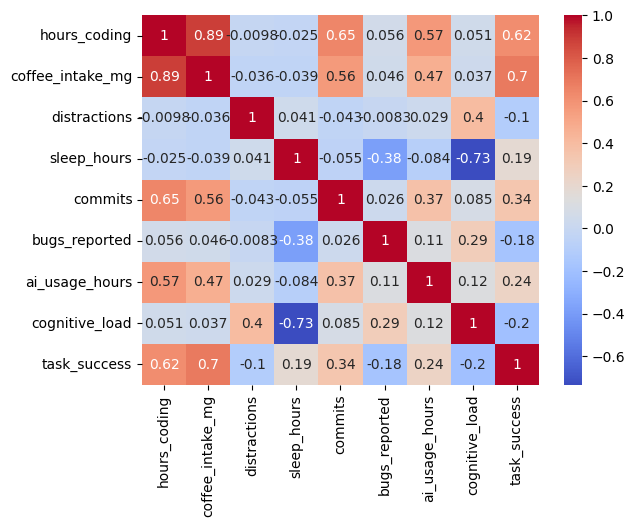

In [15]:
print("Firstly Correlated data anaysis with feature scaling : ")
sns.heatmap(dataset.corr(),annot = True, cmap = "coolwarm")

As we see :
*   Amount of coffee intake is highly dependent with hours_coding,commits and ai_usage _hours and task_success
* Coffee intake is highly dependent on ai_usuage_hours and task_success
*   distraction are correlated with coginitve_load
*   sleeps hours negatively correlated with bugs_reported and coginitive load
These are major insights but we don't know about with how much coffee intake does each factor is highly dependent.
So,for there distribution **Data Visualization** is used





In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Columns of dataset are : {dataset.columns}')

Columns of dataset are : Index(['hours_coding', 'coffee_intake_mg', 'distractions', 'sleep_hours',
       'commits', 'bugs_reported', 'ai_usage_hours', 'cognitive_load',
       'task_success'],
      dtype='object')


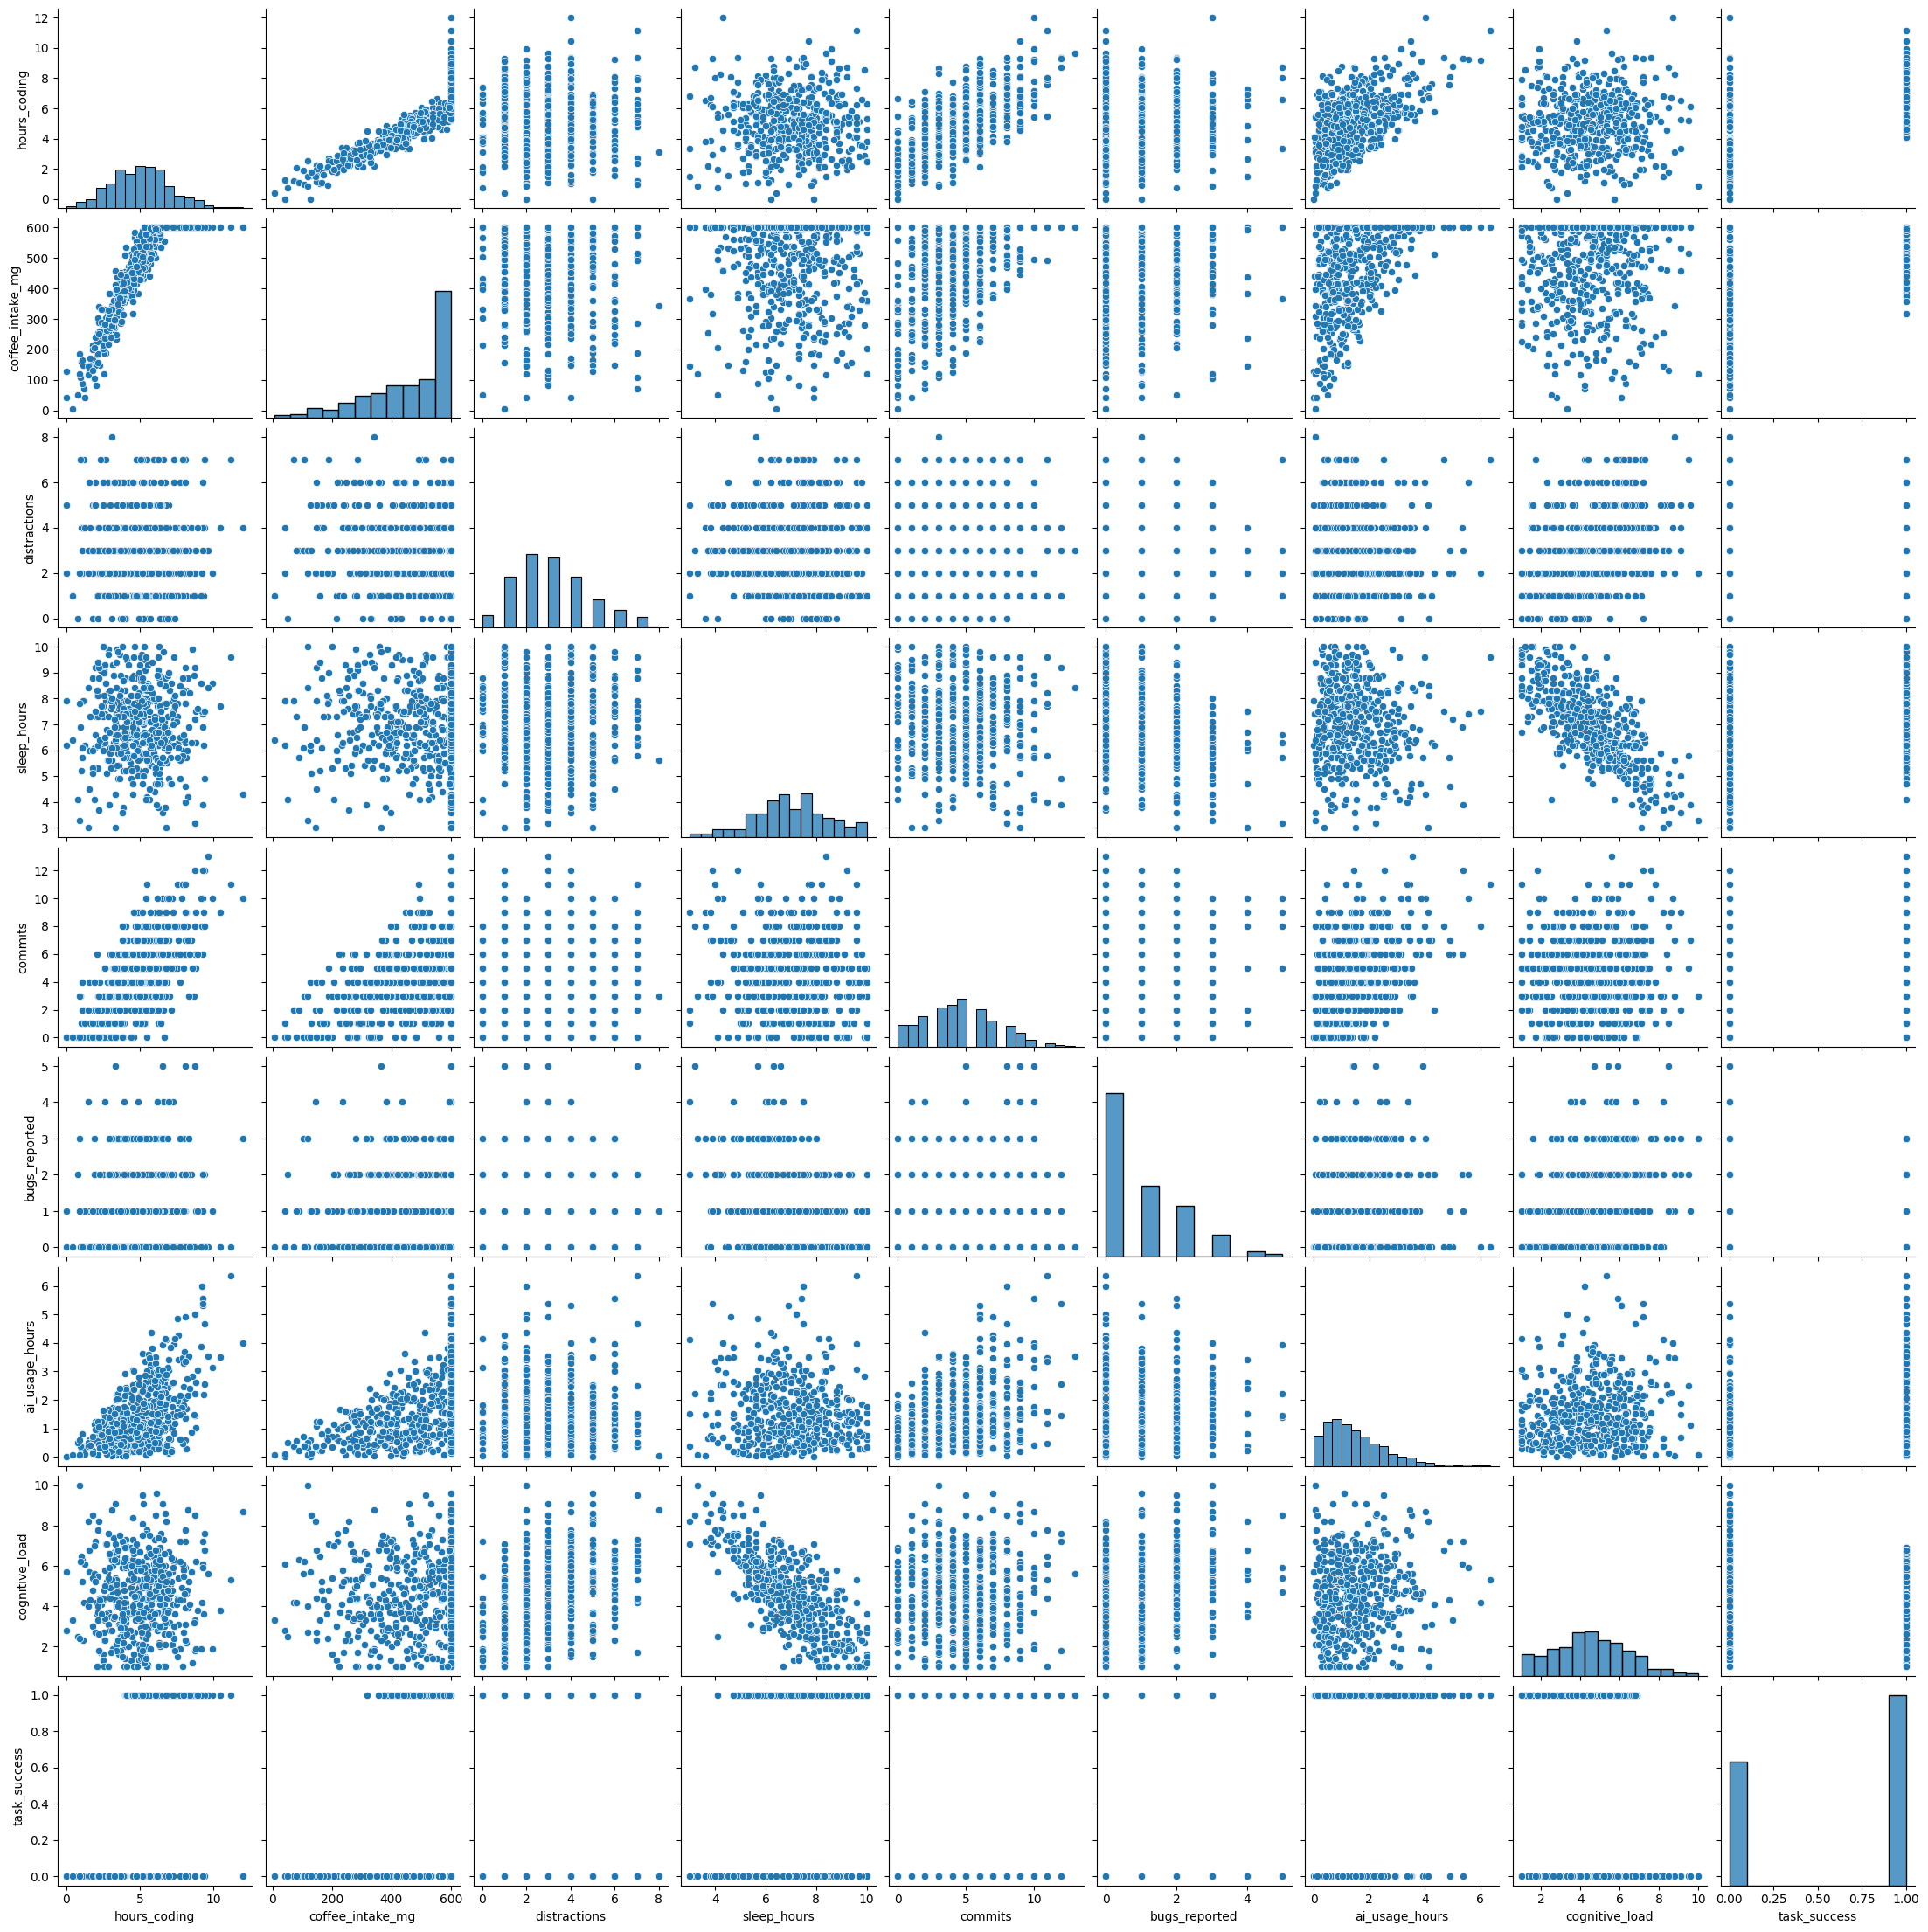

In [9]:
sns.pairplot(dataset)
# Visualization of correlation table

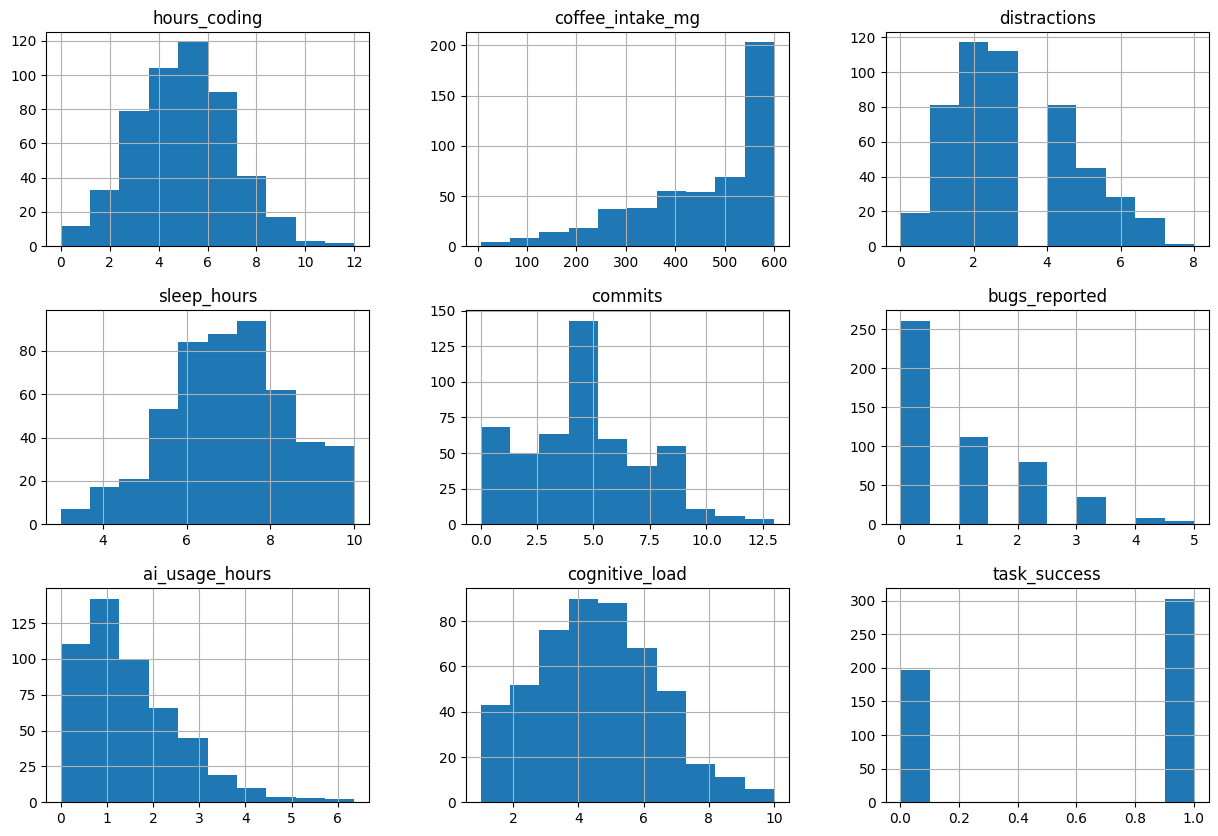

In [10]:
dataset.hist(figsize=(15,10))
plt.show()


From the further more analysis:

*  More than 400mg intake caffiene causes negative sideeffects,and data shows that almost mostly employee take equivalent to 400mg or more that 400 mg.
*  As hours_coding increases ai_usuage shows gradual change



In [11]:
dataset.describe()

,hours_coding,coffee_intake_mg,distractions,sleep_hours,commits,bugs_reported,ai_usage_hours,cognitive_load,task_success
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,5.015600,463.192000,2.976000,6.975800,4.60800,0.858000,1.510920,4.498200,0.606000
std,1.947253,142.334991,1.678409,1.455965,2.70499,1.102846,1.085557,1.868861,0.489124
min,0.000000,6.000000,0.000000,3.000000,0.00000,0.000000,0.000000,1.000000,0.000000
25%,3.600000,369.500000,2.000000,6.100000,3.00000,0.000000,0.697500,3.175000,0.000000
50%,5.030000,500.500000,3.000000,6.950000,5.00000,0.000000,1.260000,4.400000,1.000000
75%,6.275000,600.000000,4.000000,7.900000,6.00000,2.000000,2.070000,5.800000,1.000000
max,12.000000,600.000000,8.000000,10.000000,13.00000,5.000000,6.360000,10.000000,1.000000


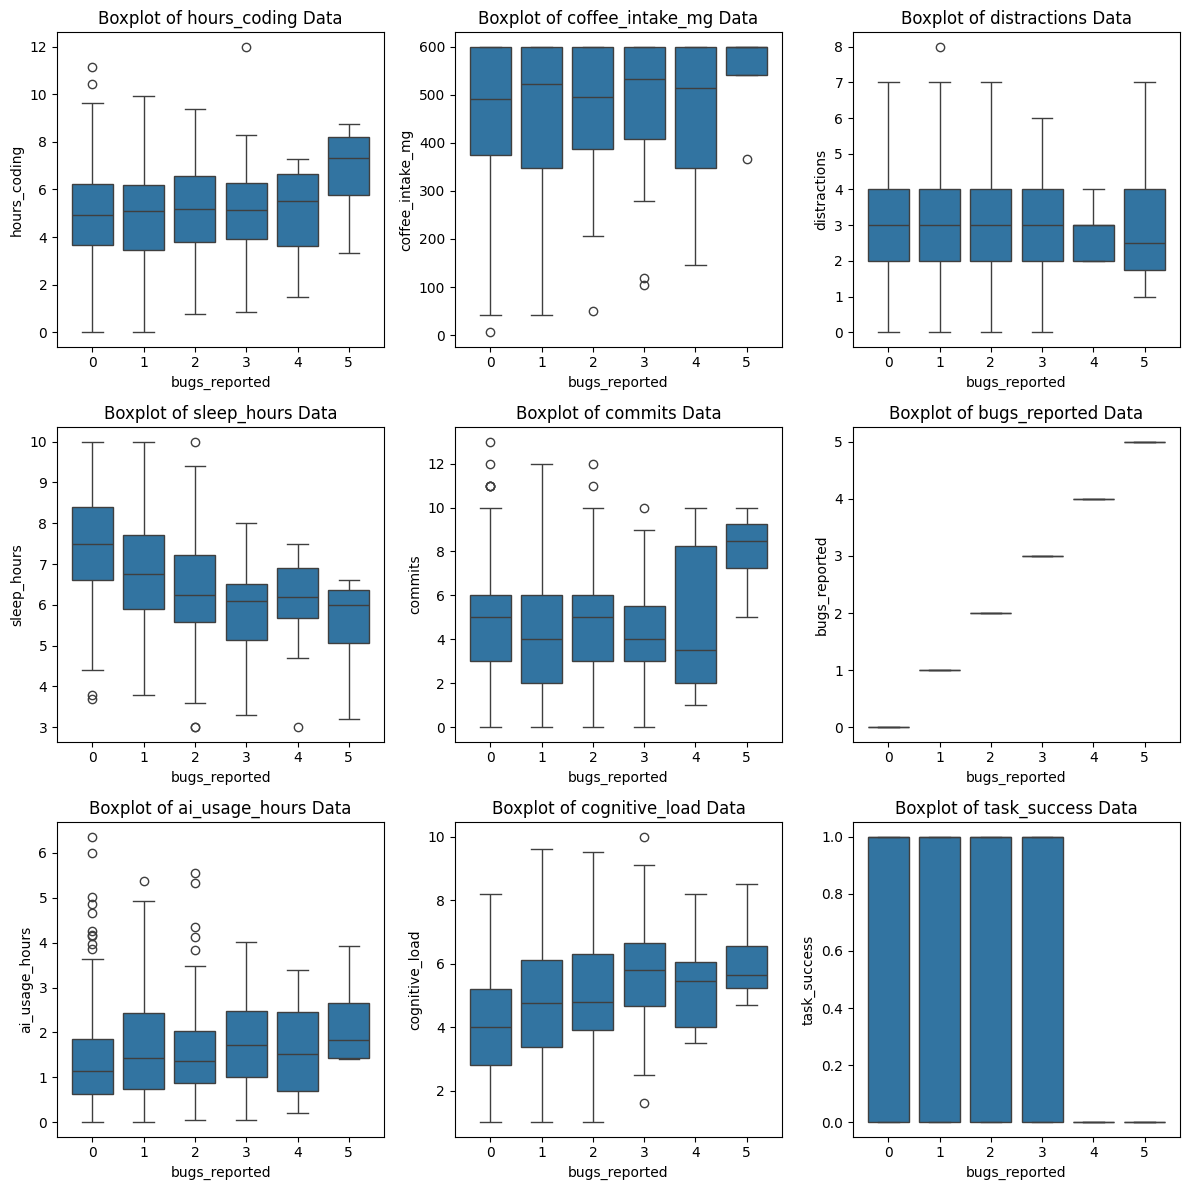

In [94]:
plt.figure(figsize = (12, 12))
for i, column in enumerate(dataset.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x = 'bugs_reported',y = column,data = dataset)
    plt.title(f"Boxplot of {column} Data")
    plt.tight_layout()
    plt.plot()

As we see these are some traits:


*   Programmer that report 4-5 bugs : has more hors of coding,more caffenie intake,less sleep hours,more commits,more ai usuage,more cogintive load,and no task success
*    Programmer that report (0-3) bugs : show some same or different kind of trend



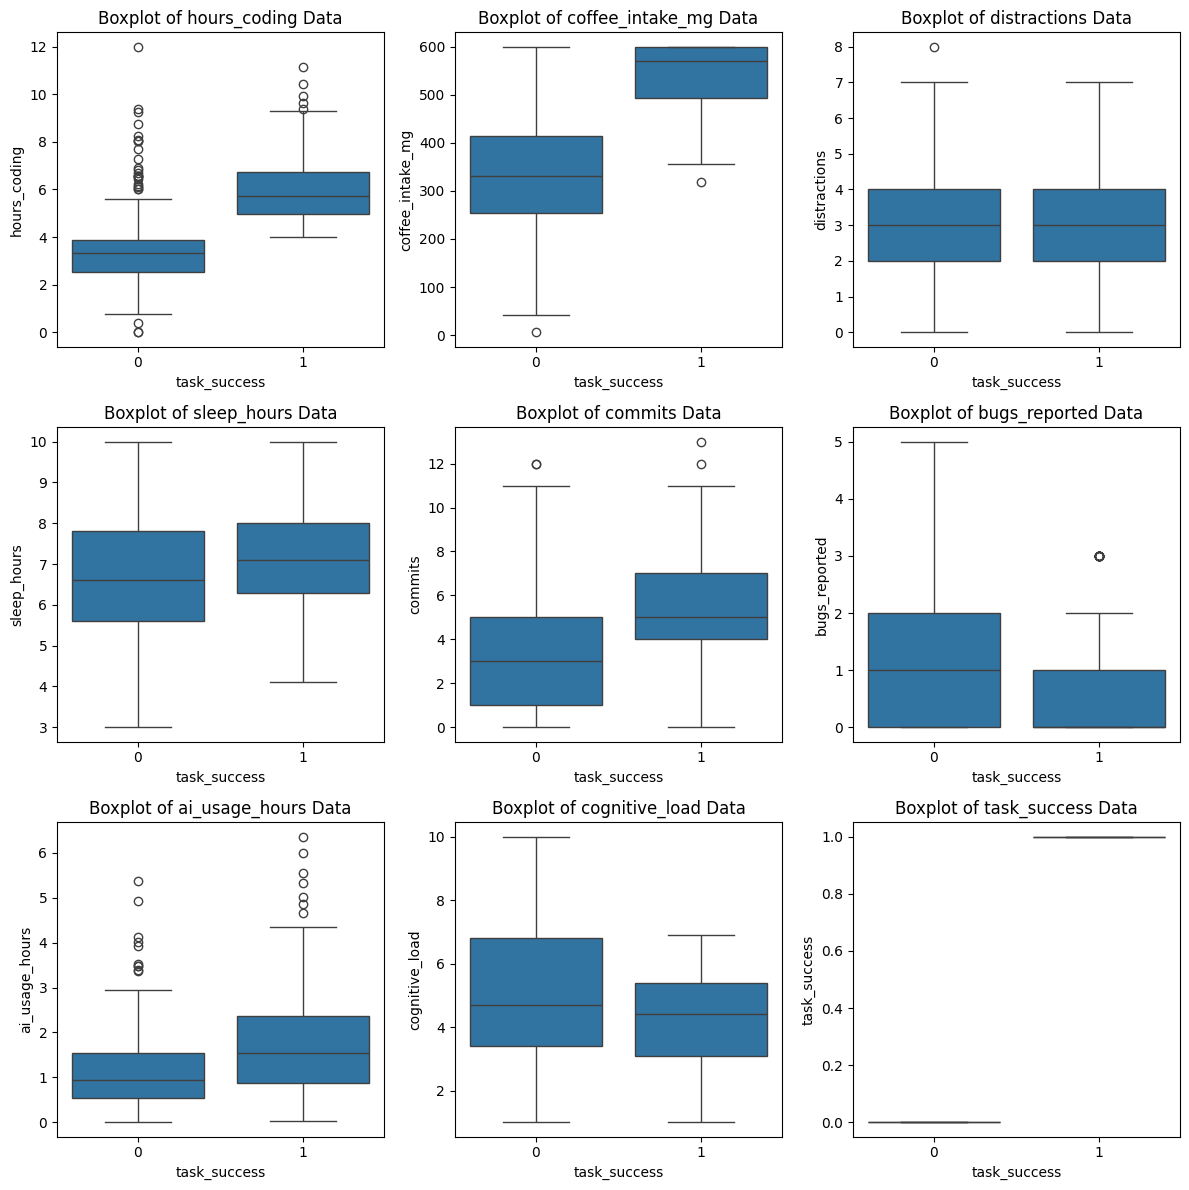

In [93]:
plt.figure(figsize = (12, 12))
for i, column in enumerate(dataset.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x = 'task_success',y = column,data = dataset)
    plt.title(f"Boxplot of {column} Data")
    plt.tight_layout()
    plt.plot()

Task success programmer usually has more hours coding,cofee_intake,commits,less bug reported,more ai_usuage(1 -> shows successful day)

Text Splitting for model training

---



In [22]:
data = dataset.drop('task_success',axis = 1)
target = dataset['task_success']

In [23]:
from sklearn.model_selection import train_test_split
train_data,test_data,train_target,test_target = train_test_split(data,target,test_size = 0.2,random_state = 42,shuffle = True)

**Logistic Regression Model for training**

In [95]:
# Make a predictive model for Binary Classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression()
model.fit(train_data,train_target)
y_pred = model.predict(test_data)

#Measuring accuracy score and classification_report

accuracy = accuracy_score(test_target,y_pred)
classification_report = classification_report(test_target,y_pred)
print(f'Accuracy Score : {accuracy}')
print(f'Classification Report : \n{classification_report}')

Accuracy Score : 0.83
Classification Report : 
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        34
           1       0.89      0.85      0.87        66

    accuracy                           0.83       100
   macro avg       0.81      0.82      0.81       100
weighted avg       0.83      0.83      0.83       100



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


*   0(for no task success) -> Model doesn't perform well
*   1(task success)it performs well.



**SVM Model**



---
(I try standardization but it worsen the performance of model.So, i don't show it)




In [98]:
from sklearn.svm import SVC
model_1 = SVC()
model_1.fit(train_data,train_target)
y_pred_1 = model_1.predict(test_data)

#Measuring accuracy score and classification_report
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(test_target,y_pred_1)
svm_classification_report_str = classification_report(test_target,y_pred_1)
print(f'Accuracy Score : {accuracy}')
print(f'Classification Report : \n{svm_classification_report_str}')

Accuracy Score : 0.87
Classification Report : 
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        34
           1       0.86      0.95      0.91        66

    accuracy                           0.87       100
   macro avg       0.88      0.83      0.85       100
weighted avg       0.87      0.87      0.87       100



SVM Model shows improvement over Logistic Regression

**Random Forest Classifier Model**

In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import cross_val_score

model_2 = RandomForestClassifier(n_estimators =8,max_depth = 2)
model_2.fit(train_data,train_target)
y_pred_2 = model_2.predict(test_data)

#For measuring Accuracy and Classification Report
accuracy = accuracy_score(test_target,y_pred_2)
classification_report_rf = classification_report(test_target,y_pred_2)

print(f'Accuracy Score : {accuracy}')
print(f'Classification Report : \n{classification_report_rf}')


# For Cross-Validation to find a stable model



scores = cross_val_score(model_2,data,target, cv = 6, scoring='f1')
print(f"All F1 Scores: {scores}")
print(f"Average F1: {scores.mean():.2f}")

Accuracy Score : 0.98
Classification Report : 
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       0.98      0.98      0.98        66

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

All F1 Scores: [0.97142857 0.97142857 0.93577982 0.9245283  0.97087379 0.96      ]
Average F1: 0.96


For Checking Overfitting Using Random Forest Regressor Tree

In [97]:
from sklearn.metrics import classification_report

# 1. Get predictions for both sets
train_preds = model_2.predict(train_data)
test_preds = model_2.predict(test_data)

# 2. Compare the reports
print("--- TRAINING REPORT (Seen Data) ---")
print(classification_report(train_target, train_preds))

print("\n--- TEST REPORT (Unseen Data) ---")
print(classification_report(test_target, test_preds))

--- TRAINING REPORT (Seen Data) ---
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       163
           1       0.98      1.00      0.99       237

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400


--- TEST REPORT (Unseen Data) ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       0.98      0.98      0.98        66

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

